In [18]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── helpers ──────────────────────────────────────────────────────────────
def parse_iperf(path):
    """Extract per-second Mbits/sec from an iperf3 log file."""
    rates = []
    pattern = re.compile(r'\d+\.\d+-\s*\d+\.\d+\s+sec.*?([\d.]+)\s+Mbits/sec')
    with open(path) as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rates.append(float(m.group(1)))
    return np.array(rates)

def parse_slot_times(path):
    """Read one integer per line (slot completion time in µs)."""
    with open(path) as f:
        return np.array([int(l.strip()) for l in f if l.strip()])

def make_cdf(data):
    s = np.sort(data)
    p = np.arange(1, len(s) + 1) / len(s)
    return s, p

# ── load iperf throughput ────────────────────────────────────────────────
c_dl  = parse_iperf('iperf3_c_dl')
c_ul  = parse_iperf('iperf3_c_ul')
nc_dl = parse_iperf('iperf_nc_dl')
nc_ul = parse_iperf('iperf3_nc_ul')

# ── load slot completion times ───────────────────────────────────────────
nc_idle   = parse_slot_times('nc_connnect')
nc_ping   = parse_slot_times('nc_ping')
nc_ipdl   = parse_slot_times('nc_iperfdl')
nc_ipul   = parse_slot_times('nc_iperful')

c_idle    = parse_slot_times('c_connect')
c_ping    = parse_slot_times('c_ping')
c_ipdl    = parse_slot_times('c_iperfdl')
c_ipul    = parse_slot_times('c_iperful')

for name, arr in [
    ('NC Idle', nc_idle), ('NC Ping', nc_ping), ('NC DL', nc_ipdl), ('NC UL', nc_ipul),
    ('C  Idle', c_idle),  ('C  Ping', c_ping),  ('C  DL', c_ipdl),  ('C  UL', c_ipul),
]:
    print(f'{name}: n={len(arr):6d}  mean={arr.mean():6.0f} µs  p99={np.percentile(arr,99):6.0f} µs')


NC Idle: n= 99999  mean=  1111 µs  p99=  1656 µs
NC Ping: n= 99999  mean=  1037 µs  p99=  1622 µs
NC DL: n= 99999  mean=  1561 µs  p99=  2683 µs
NC UL: n= 99999  mean=  1856 µs  p99=  2394 µs
C  Idle: n= 99999  mean=  1005 µs  p99=  1007 µs
C  Ping: n= 99999  mean=  1005 µs  p99=  1008 µs
C  DL: n= 99999  mean=  1016 µs  p99=  1021 µs
C  UL: n= 99999  mean=  1019 µs  p99=  1025 µs


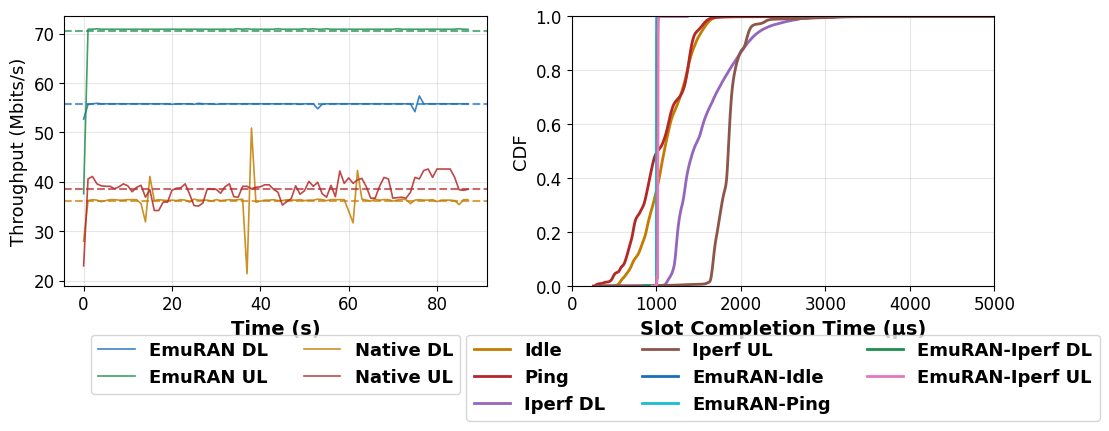

Saved fig30.pdf


In [29]:
# ── plot ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 3.5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

FONT     = 13
XLABEL_F = 14

LEGEND_KW = dict(fontsize=FONT, loc='upper center',
                 bbox_to_anchor=(0.5, -0.18),
                 prop={'weight': 'bold', 'size': FONT},
                 frameon=True, borderaxespad=0)

# ── colors ───────────────────────────────────────────────────────────────
TP_COLORS = {
    'emuran_dl': '#1a6fbd',
    'emuran_ul': '#1e8f4e',
    'native_dl': '#c47d00',
    'native_ul': '#b52828',
}

CDF_COLORS = {
    'nc_idle': '#c47d00',
    'nc_ping': '#b52828',
    'nc_dl':   '#9467bd',
    'nc_ul':   '#8c564b',
    'c_idle':  '#1a6fbd',
    'c_ping':  '#17becf',
    'c_dl':    '#1e8f4e',
    'c_ul':    '#e377c2',
}

# ── (a) Throughput ───────────────────────────────────────────────────────
ax_tp = fig.add_subplot(gs[0])

for data, label, color in [
    (c_dl[:88],  'EmuRAN DL', TP_COLORS['emuran_dl']),
    (c_ul[:88],  'EmuRAN UL', TP_COLORS['emuran_ul']),
    (nc_dl[:88], 'Native DL', TP_COLORS['native_dl']),
    (nc_ul[:88], 'Native UL', TP_COLORS['native_ul']),
]:
    ax_tp.plot(data, color=color, alpha=0.85, linewidth=1.2, label=label)
    ax_tp.axhline(data.mean(), color=color, linestyle='--', linewidth=1.5, alpha=0.7)

ax_tp.set_xlabel('Time (s)', fontsize=XLABEL_F, fontweight='bold')
ax_tp.set_ylabel('Throughput (Mbits/s)', fontsize=FONT)
# ax_tp.set_title('(a) Throughput', fontsize=FONT+1, fontweight='bold')
ax_tp.tick_params(labelsize=FONT-1)
ax_tp.grid(True, alpha=0.3)
ax_tp.legend(ncol=2, **LEGEND_KW)

# ── (b) CDF of slot completion time ──────────────────────────────────────
ax_cdf = fig.add_subplot(gs[1])

cdf_traces = [
    (nc_idle, 'Idle',             CDF_COLORS['nc_idle']),
    (nc_ping, 'Ping',             CDF_COLORS['nc_ping']),
    (nc_ipdl, 'Iperf DL',        CDF_COLORS['nc_dl']),
    (nc_ipul, 'Iperf UL',        CDF_COLORS['nc_ul']),
    (c_idle,  'EmuRAN-Idle',     CDF_COLORS['c_idle']),
    (c_ping,  'EmuRAN-Ping',     CDF_COLORS['c_ping']),
    (c_ipdl,  'EmuRAN-Iperf DL', CDF_COLORS['c_dl']),
    (c_ipul,  'EmuRAN-Iperf UL', CDF_COLORS['c_ul']),
]

for data, label, color in cdf_traces:
    x, y = make_cdf(data)
    ax_cdf.plot(x, y, color=color, linewidth=2, label=label)

ax_cdf.set_xlabel('Slot Completion Time (µs)', fontsize=XLABEL_F, fontweight='bold')
ax_cdf.set_ylabel('CDF', fontsize=FONT)
# ax_cdf.set_title('(b) Slot Completion Time CDF', fontsize=FONT+1, fontweight='bold')
ax_cdf.set_ylim(0, 1)
ax_cdf.set_xlim(0, 5000)
ax_cdf.tick_params(labelsize=FONT-1)
ax_cdf.grid(True, alpha=0.3)
ax_cdf.legend(ncol=3, **LEGEND_KW)

plt.savefig('fig30.pdf', bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig30.pdf')
